In [8]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print(f"NetworkX version: {nx.__version__}")

NetworkX version: 3.6.1


In [9]:
X_train = pd.read_csv(r'd:\Projects\credit-risk-network\data\processed\X_train.csv')
y_train = pd.read_csv(r'd:\Projects\credit-risk-network\data\processed\y_train.csv').squeeze()

# Work with a sample of 5000 for network construction (full 120k would be too large)
np.random.seed(42)
sample_idx = np.random.choice(len(X_train), 5000, replace=False)
X_sample = X_train.iloc[sample_idx].reset_index(drop=True)
y_sample = y_train.iloc[sample_idx].reset_index(drop=True)

print(f"Working with {len(X_sample)} borrowers")
print(f"Default rate in sample: {y_sample.mean():.3f}")

Working with 5000 borrowers
Default rate in sample: 0.063


In [16]:
from sklearn.metrics.pairwise import euclidean_distances

# Use key financial features for similarity
network_features = ['RevolvingUtilizationOfUnsecuredLines', 'age','DebtRatio', 'MonthlyIncome', 'NumberOfDependents']

X_network = X_sample[network_features].values

# Compute pairwise distances
print("Computing pairwise distances...")
distances = euclidean_distances(X_network)

# Convert to similarity (closer = more similar)
# Connect two borrowers if they are in the top 5% most similar pairs
threshold = np.percentile(distances[distances > 0], 5)
print(f"Similarity threshold: {threshold:.4f}")

# Build graph
print("Building graph...")
G = nx.Graph()

# Add nodes
for i in range(len(X_sample)):
    G.add_node(i, default=int(y_sample[i]))

# Add edges for similar borrowers
for i in range(len(X_sample)):
    for j in range(i+1, len(X_sample)):
        if distances[i][j] <= threshold:
            G.add_edge(i, j)

print(f"\n=== NETWORK STATS ===")
print(f"Nodes: {G.number_of_nodes():,}")
print(f"Edges: {G.number_of_edges():,}")
print(f"Average degree: {sum(dict(G.degree()).values())/G.number_of_nodes():.2f}")
print(f"Network density: {nx.density(G):.6f}")


Computing pairwise distances...
Similarity threshold: 1.0787
Building graph...

=== NETWORK STATS ===
Nodes: 5,000
Edges: 624,880
Average degree: 249.95
Network density: 0.050000


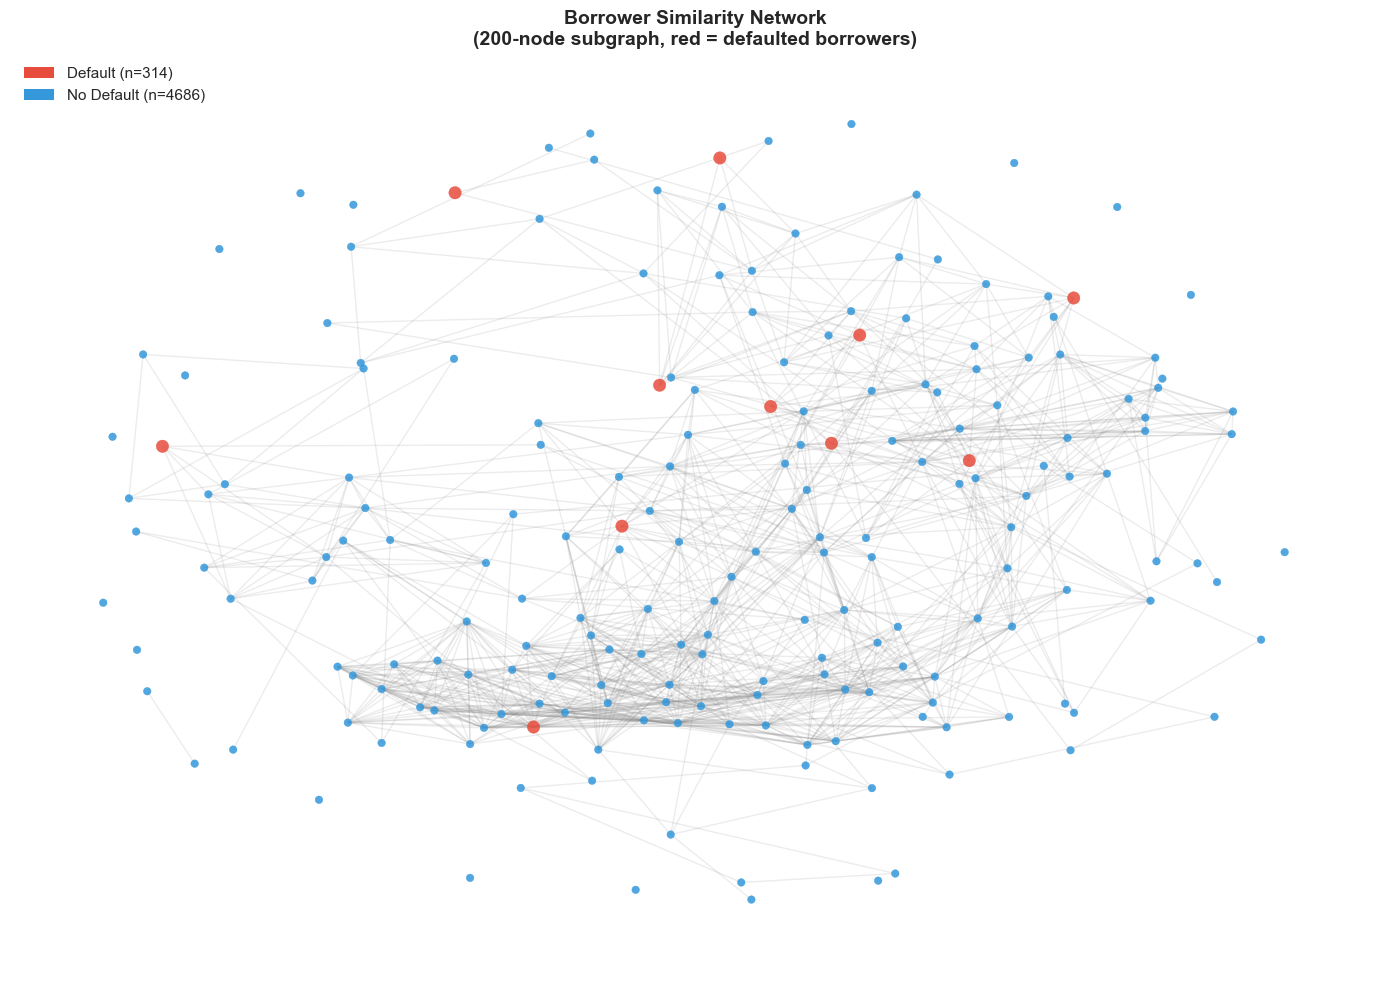

Network visualization saved.


In [17]:
# Take a subgraph of 200 nodes for visualization
np.random.seed(42)
sub_nodes = np.random.choice(list(G.nodes()), 200, replace=False)
subgraph = G.subgraph(sub_nodes)

# Color nodes by default status
node_colors = ['#e74c3c' if G.nodes[n]['default'] == 1 else '#3498db' for n in subgraph.nodes()]

node_sizes = [80 if G.nodes[n]['default'] == 1 else 30 for n in subgraph.nodes()]

fig, ax = plt.subplots(figsize=(14, 10))

pos = nx.spring_layout(subgraph, seed=42, k=0.5)

nx.draw_networkx_edges(subgraph, pos, alpha=0.15, edge_color='gray', ax=ax)
nx.draw_networkx_nodes(subgraph, pos, node_color=node_colors,node_size=node_sizes, alpha=0.85, ax=ax)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label=f'Default (n={y_sample.sum()})'),
    Patch(facecolor='#3498db', label=f'No Default (n={len(y_sample)-y_sample.sum()})')]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11)

ax.set_title('Borrower Similarity Network\n(200-node subgraph, red = defaulted borrowers)',fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig(r'd:\Projects\credit-risk-network\outputs\plots\07_borrower_network.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Network visualization saved.")

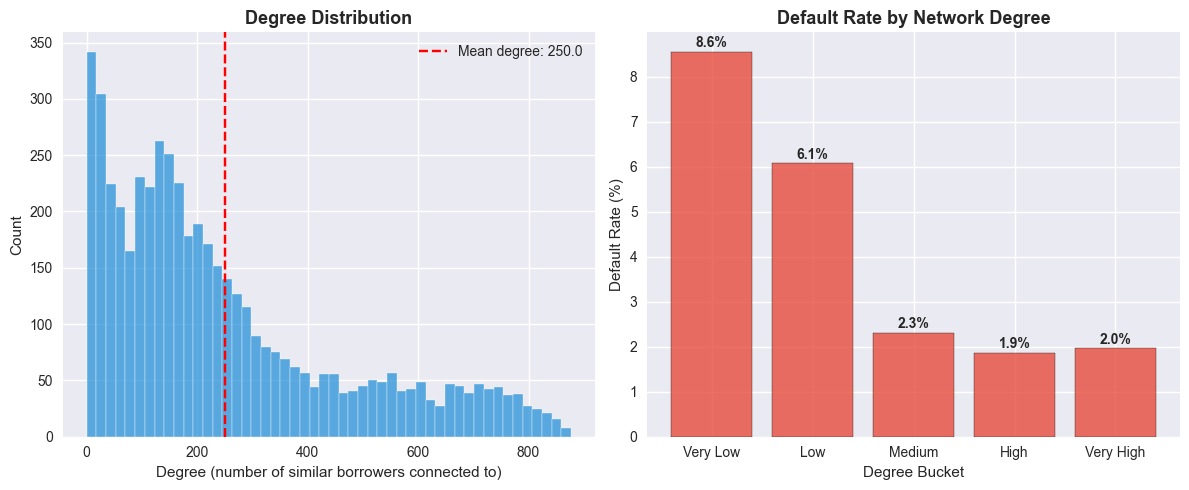

Network analysis plots saved.


In [18]:
# Degree distribution
degrees = [d for n, d in G.degree()]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Degree distribution
axes[0].hist(degrees, bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_title('Degree Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Degree (number of similar borrowers connected to)')
axes[0].set_ylabel('Count')
axes[0].axvline(np.mean(degrees), color='red', linestyle='--', 
                label=f'Mean degree: {np.mean(degrees):.1f}')
axes[0].legend()

# Default rate by degree bucket
degree_dict = dict(G.degree())
X_sample['degree'] = [degree_dict[i] for i in range(len(X_sample))]
X_sample['default'] = y_sample.values

X_sample['degree_bucket'] = pd.cut(X_sample['degree'],bins=5,labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

default_by_degree = X_sample.groupby('degree_bucket', observed=True)['default'].mean() * 100

axes[1].bar(default_by_degree.index, default_by_degree.values,color='#e74c3c', edgecolor='black', alpha=0.8)
axes[1].set_title('Default Rate by Network Degree', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Degree Bucket')
axes[1].set_ylabel('Default Rate (%)')

for i, (idx, val) in enumerate(default_by_degree.items()):
    axes[1].text(i, val + 0.1, f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(r'd:\Projects\credit-risk-network\outputs\plots\08_network_analysis.png',dpi=150, bbox_inches='tight')
plt.show()

X_sample.drop(['degree', 'default', 'degree_bucket'], axis=1, inplace=True)
print("Network analysis plots saved.")

In [19]:
communities = nx.community.louvain_communities(G, seed=42)
partition = {}
for comm_id, comm in enumerate(communities):
    for node in comm:
        partition[node] = comm_id

print(f"Communities found: {len(communities)}")

Communities found: 33


In [20]:
community_df = pd.DataFrame({
    'node': list(partition.keys()),
    'community': list(partition.values()),
    'default': [G.nodes[n]['default'] for n in partition.keys()]
})

community_stats = community_df.groupby('community').agg(
    size=('node', 'count'),
    default_rate=('default', 'mean')
).reset_index()

community_stats['default_rate'] = (community_stats['default_rate'] * 100).round(2)
community_stats = community_stats.sort_values('default_rate', ascending=False)

# Only look at communities with reasonable size (filter out tiny ones)
community_stats_filtered = community_stats[community_stats['size'] >= 5]

print(f"Total communities: {len(community_stats)}")
print(f"Communities with 5+ members: {len(community_stats_filtered)}")
print(f"\nTop 5 highest risk communities:")
print(community_stats_filtered.head())
print(f"\nBottom 5 lowest risk communities:")
print(community_stats_filtered.tail())

Total communities: 33
Communities with 5+ members: 9

Top 5 highest risk communities:
    community  size  default_rate
7           7     6         33.33
13         13  1308         15.37
5           5   491          5.09
22         22   818          3.42
16         16   719          3.34

Bottom 5 lowest risk communities:
    community  size  default_rate
16         16   719          3.34
0           0   735          2.72
25         25    86          2.33
1           1   802          1.50
24         24    10          0.00


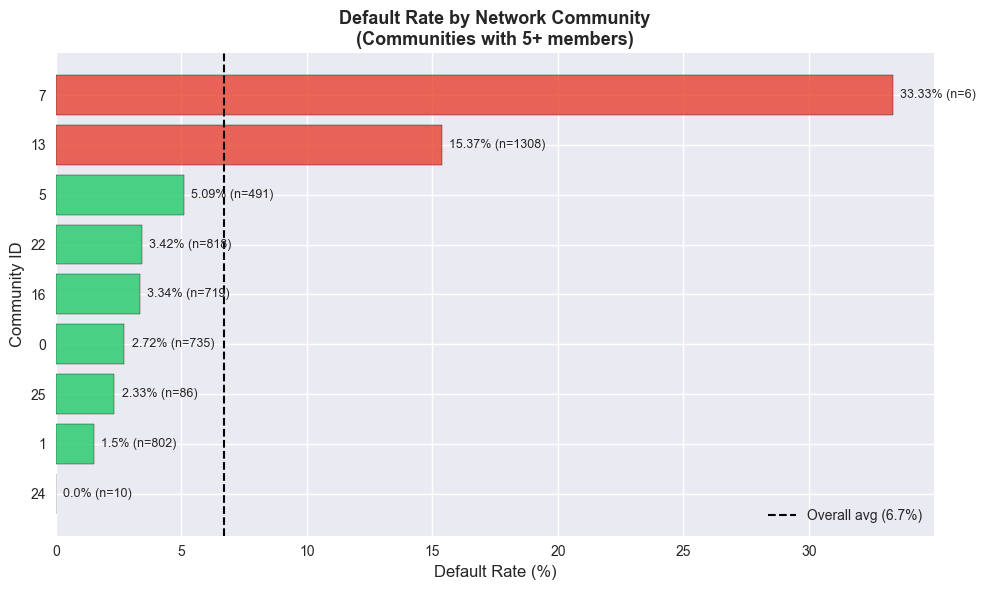

Plot saved.


In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

plot_data = community_stats_filtered.sort_values('default_rate', ascending=True)
colors = ['#2ecc71' if x < 6.7 else '#e74c3c' for x in plot_data['default_rate']]

bars = ax.barh(plot_data['community'].astype(str), plot_data['default_rate'], 
               color=colors, edgecolor='black', alpha=0.85)

ax.axvline(6.7, color='black', linestyle='--', linewidth=1.5, label='Overall avg (6.7%)')

for i, (comm, rate, size) in enumerate(zip(plot_data['community'], 
                                             plot_data['default_rate'], 
                                             plot_data['size'])):
    ax.text(rate + 0.3, i, f'{rate}% (n={size})', va='center', fontsize=9)

ax.set_xlabel('Default Rate (%)', fontsize=12)
ax.set_ylabel('Community ID', fontsize=12)
ax.set_title('Default Rate by Network Community\n(Communities with 5+ members)', 
             fontsize=13, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(r'd:\Projects\credit-risk-network\outputs\plots\09_community_risk.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

In [22]:
import pickle

with open(r'd:\Projects\credit-risk-network\outputs\models\borrower_network.pkl', 'wb') as f:
    pickle.dump(G, f)

with open(r'd:\Projects\credit-risk-network\outputs\models\community_partition.pkl', 'wb') as f:
    pickle.dump(partition, f)

np.save(r'd:\Projects\credit-risk-network\outputs\models\sample_idx.npy', sample_idx)

community_stats.to_csv(r'd:\Projects\credit-risk-network\outputs\reports\community_risk_stats.csv', index=False)

print("=== NETWORK CONSTRUCTION COMPLETE ===")
print(f"Network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Communities found: {len(communities)}")
print(f"Highest risk community: {community_stats_filtered.iloc[0]['default_rate']}% default rate")
print(f"Lowest risk community: {community_stats_filtered.iloc[-1]['default_rate']}% default rate")

=== NETWORK CONSTRUCTION COMPLETE ===
Network: 5000 nodes, 624880 edges
Communities found: 33
Highest risk community: 33.33% default rate
Lowest risk community: 0.0% default rate

Ready for Notebook 5: Extract graph features for ML model
